2025-02-13 10:34:28,989 - INFO - Loading spectral data...
2025-02-13 10:34:28,991 - INFO - Processing XYZ data...
2025-02-13 10:34:28,991 - INFO - Normalizing data...
2025-02-13 10:34:28,992 - INFO - Augmenting training data with varying exposures...
2025-02-13 10:34:28,993 - INFO - Training the model...
2025-02-13 10:34:29,001 - INFO - Epoch 1/300 - MSE Loss: 0.05695724859833717
2025-02-13 10:34:29,007 - INFO - Epoch 2/300 - MSE Loss: 0.0648033395409584
2025-02-13 10:34:29,013 - INFO - Epoch 3/300 - MSE Loss: 0.025220399722456932
2025-02-13 10:34:29,018 - INFO - Epoch 4/300 - MSE Loss: 0.04984120652079582


2025-02-13 10:34:29,024 - INFO - Epoch 5/300 - MSE Loss: 0.05339965224266052
2025-02-13 10:34:29,030 - INFO - Epoch 6/300 - MSE Loss: 0.031227873638272285
2025-02-13 10:34:29,040 - INFO - Epoch 7/300 - MSE Loss: 0.0313371978700161
2025-02-13 10:34:29,045 - INFO - Epoch 8/300 - MSE Loss: 0.04590308666229248
2025-02-13 10:34:29,050 - INFO - Epoch 9/300 - MSE Loss: 0.05046446621417999
2025-02-13 10:34:29,056 - INFO - Epoch 10/300 - MSE Loss: 0.0422990657389164
2025-02-13 10:34:29,061 - INFO - Epoch 11/300 - MSE Loss: 0.037482570856809616
2025-02-13 10:34:29,066 - INFO - Epoch 12/300 - MSE Loss: 0.04309777542948723
2025-02-13 10:34:29,072 - INFO - Epoch 13/300 - MSE Loss: 0.03102133236825466
2025-02-13 10:34:29,079 - INFO - Epoch 14/300 - MSE Loss: 0.07923641055822372
2025-02-13 10:34:29,085 - INFO - Epoch 15/300 - MSE Loss: 0.017667734995484352
2025-02-13 10:34:29,090 - INFO - Epoch 16/300 - MSE Loss: 0.037742603570222855
2025-02-13 10:34:29,095 - INFO - Epoch 17/300 - MSE Loss: 0.0357457

Mean ΔE2000 Error: 12.712802471289457
Max ΔE2000 Error: 59.38336383416524


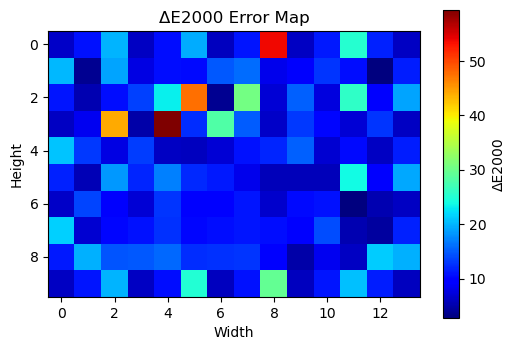

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import MinMaxScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # If using GPU

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_xyz(cube, bands, ill, CMFs):
    """
    Converts hyperspectral cube data to XYZ.
    """
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    return xyz

def augment_exposure(data, exposure_factors):
    """
    Augments data by scaling pixel values to simulate different exposure levels.
    
    Parameters:
    - data: numpy array of shape (num_samples, height, width, channels)
    - exposure_factors: list of factors to scale the pixel values
    
    Returns:
    - augmented_data: numpy array containing the augmented samples
    """
    augmented_data = []
    for factor in exposure_factors:
        augmented = data * factor
        # Clip values to maintain valid range
        augmented = np.clip(augmented, 0, 1)
        augmented_data.append(augmented)
    return np.vstack(augmented_data)

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube = spectral.open_image('../../data/colorChecker_SG/cubes/cubeCC_120f-velvia-f8.hdr')
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process XYZ data
###########################################
logging.info('Processing XYZ data...')
xyz_input = process_xyz(cube_data, wl_input, ill, CMFs)   
xyz_ref   = process_xyz(cube_ref_data, wl_ref, ill, CMFs)   

###########################################
# 3. Normalize data
###########################################
logging.info('Normalizing data...')
xyz_input_2d = xyz_input.reshape(-1, xyz_input.shape[-1])
xyz_ref_2d   = xyz_ref.reshape(-1, xyz_ref.shape[-1])

scaler_input = MinMaxScaler()
scaler_ref = MinMaxScaler()
X_norm = scaler_input.fit_transform(xyz_input_2d)
Y_norm = scaler_ref.fit_transform(xyz_ref_2d)

X_full = X_norm.reshape(xyz_input.shape)
Y_full = Y_norm.reshape(xyz_ref.shape)

###########################################
# 4. Prepare training data with exposure augmentation
###########################################
logging.info('Augmenting training data with varying exposures...')
exposure_factors = [0.5, 1.0, 1.5]  # Simulate underexposure and overexposure
X_augmented = augment_exposure(X_full, exposure_factors)
Y_augmented = np.tile(Y_full, (len(exposure_factors), 1, 1, 1))

X_flat = X_augmented.reshape(-1, 3)
Y_flat = Y_augmented.reshape(-1, 3)

n_pixels = X_flat.shape[0]
train_size = int(0.8 * n_pixels)
train_indices = np.random.choice(n_pixels, train_size, replace=False)
test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

X_train_split = X_flat[train_indices]
X_test_split  = X_flat[test_indices]
Y_train_split = Y_flat[train_indices]
Y_test_split  = Y_flat[test_indices]

X_train_torch = torch.tensor(X_train_split, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train_split, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_split, dtype=torch.float32)
Y_test_torch  = torch.tensor(Y_test_split, dtype=torch.float32)

###########################################
# 5. Define the Exposure-Invariant Neural Network
###########################################
class ExposureInvariantNN(nn.Module):
    def __init__(self, input_size=2, hidden_size=79, hidden_size2=36, output_size=3):
        super(ExposureInvariantNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(hidden_size, hidden_size2)
        self.elu2 = nn.ELU()
        self.fc3 = nn.Linear(hidden_size2, output_size)
        self.luminance_fc = nn.Linear(1, 1)  # For predicting luminance

    def forward(self, x):
        # Normalize RGB to chromaticity
        sum_rgb = torch.sum(x, dim=1, keepdim=True) + 1e-6
        chromaticity = x[:, :2] / sum_rgb  # Assuming x is of shape (batch_size, 3)
        
        # Predict chromaticity
        chroma = self.elu(self.fc1(chromaticity))
        chroma = self.elu2(self.fc2(chroma))
        chroma = self.fc3(chroma)
        
        # Predict luminance
        luminance = self.luminance_fc(sum_rgb)
        
        # Combine chromaticity and luminance to get final XYZ
        output = chroma * luminance
        return output

model = ExposureInvariantNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()

###########################################
# 6. Training loop
###########################################
epochs = 300
batch_size = 32

logging.info('Training the model...')
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_torch.size(0))
    X_train_shuffled = X_train_torch[perm]
    Y_train_shuffled = Y_train_torch[perm]
    
    for i in range(0, X_train_shuffled.size(0), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        Y_batch = Y_train_shuffled[i:i+batch_size]
        
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = loss_function(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()
    
    logging.info(f'Epoch {epoch+1}/{epochs} - MSE Loss: {loss.item()}')

###########################################
# 7. Apply correction and evaluate
###########################################
logging.info('Applying correction to the full target...')
X_full_flat = X_full.reshape(-1, 3)
corrected_flat = model(torch.tensor(X_full_flat, dtype=torch.float32)).detach().numpy()
corrected_xyz = scaler_ref.inverse_transform(corrected_flat)
corrected_xyz_image = corrected_xyz.reshape(xyz_ref.shape)

lab_ref = color.xyz2lab(xyz_ref)
lab_corrected = color.xyz2lab(corrected_xyz_image)

# Compute ΔE2000 error map
error_map = color.deltaE_ciede2000(lab_ref, lab_corrected)

# Compute mean ΔE2000 error
mean_error = np.mean(error_map)
max_error = np.max(error_map)
logging.info(f"Mean ΔE2000 Error on test set: {mean_error}")
print("Mean ΔE2000 Error:", mean_error)
print("Max ΔE2000 Error:", max_error)

# Plot the ΔE2000 error map
plt.figure(figsize=(6, 4))
plt.imshow(error_map, cmap='jet')
plt.colorbar(label='ΔE2000')
plt.title('ΔE2000 Error Map')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()


In [3]:
print("XYZ Reference Min/Max:", xyz_ref.min(), xyz_ref.max())
print("XYZ Corrected Min/Max:", corrected_xyz_image.min(), corrected_xyz_image.max())
print("Lab Reference Min/Max:", lab_ref.min(), lab_ref.max())
print("Lab Corrected Min/Max:", lab_corrected.min(), lab_corrected.max())


XYZ Reference Min/Max: 0.008165326884412523 0.9763268813085731
XYZ Corrected Min/Max: nan nan
Lab Reference Min/Max: -55.182682004284544 96.85369494315286
Lab Corrected Min/Max: nan nan


In [6]:
corrected_flat = model(torch.tensor(X_full_flat, dtype=torch.float32)).detach().numpy()
print("Corrected Flat (Raw Model Output) Min/Max:", np.nanmin(corrected_flat), np.nanmax(corrected_flat))


Corrected Flat (Raw Model Output) Min/Max: nan nan


/tmp/ipykernel_1208478/279896962.py:2: RuntimeWarning: All-NaN slice encountered
  print("Corrected Flat (Raw Model Output) Min/Max:", np.nanmin(corrected_flat), np.nanmax(corrected_flat))
